# Chapter 3 Figures

## Kernel-Weight Method — Weight Diagnostic

Compares **γ-power** (old) vs **GLS-ESS** (new) weight computation for the
KW MC correlation method, and diagnoses how the change affects per-experiment
WLS fractions and implied correlations.

Visual encoding:
- **Marker shape** = experiment
- **Color** = effective per-point weight (continuous colormap + colorbar)
- **Black edge** = core dataset (highest overlap weight per experiment)

In [1]:
from __future__ import annotations

import sys
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy.stats import norm

# Ensure kika is importable
REPO_ROOT = Path(r"C:\Users\Usuario\BaradDur\Dev\kika")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from kika.exfor import read_all_exfor

# ── Inline pipeline functions ──────────────────────────────────────────

def compute_overlap_weight(exp_energy_mev, sigma_E_mev, bin_lower_mev, bin_upper_mev):
    """CDF-based overlap weight: P(true energy in bin).  (exfor_utils.py:439-489)"""
    if sigma_E_mev <= 0:
        return 1.0 if bin_lower_mev <= exp_energy_mev <= bin_upper_mev else 0.0
    z_high = (bin_upper_mev - exp_energy_mev) / sigma_E_mev
    z_low = (bin_lower_mev - exp_energy_mev) / sigma_E_mev
    return norm.cdf(z_high) - norm.cdf(z_low)

# TOF sigma_E (tof_parameters.py:163-217)
NEUTRON_MASS_MEV = 939.565378
SPEED_OF_LIGHT_M_NS = 0.299792458

def compute_sigma_E(energy_mev, flight_path_m, time_resolution_ns, min_sigma_E_kev=1.0):
    """Compute energy resolution sigma_E from TOF parameters."""
    if energy_mev <= 0:
        return min_sigma_E_kev / 1000.0
    velocity_m_ns = SPEED_OF_LIGHT_M_NS * np.sqrt(2.0 * energy_mev / NEUTRON_MASS_MEV)
    flight_time_ns = flight_path_m / velocity_m_ns
    sigma_E_mev = energy_mev * 2.0 * (time_resolution_ns / flight_time_ns)
    return max(sigma_E_mev, min_sigma_E_kev / 1000.0)

def get_full_subentry_id(obj):
    """Get the full EXFOR subentry ID (e.g., '10571002').
    Handles both DB format (entry='10571', subentry='002')
    and JSON format (entry='27673', subentry='27673002')."""
    if obj.subentry.startswith(obj.entry):
        return obj.subentry
    return f"{obj.entry}{obj.subentry}"

def compute_gls_ess_weight(n_j, sigma_norm, rms_rel_stat):
    """GLS-ESS per-point weight: g = 1 / (1 + (n-1)*rho).

    Parameters
    ----------
    n_j : int  — number of angular points for the experiment
    sigma_norm : float — shared normalization uncertainty (relative)
    rms_rel_stat : float — RMS relative statistical uncertainty (post-floor)

    Returns
    -------
    g : float — per-point weight
    rho : float — equicorrelation coefficient
    n_eff : float — effective sample size
    """
    if not np.isfinite(rms_rel_stat) or rms_rel_stat <= 0:
        return np.nan, np.nan, np.nan
    rho = sigma_norm**2 / (sigma_norm**2 + rms_rel_stat**2)
    n_eff = n_j / (1.0 + max(n_j - 1, 0) * rho)
    g = 1.0 / (1.0 + max(n_j - 1, 0) * rho)
    return g, rho, n_eff

# ── Constants ──────────────────────────────────────────────────────────

MARKERS = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
CMAP = plt.cm.plasma

# Data paths
#DB_PATH = r"c:\Users\Usuario\BaradDur\EXFOR\x4sqlite-20251105-c\x4sqlite1.db"
#SUPPLEMENTARY_JSON = r"c:\Users\Usuario\BaradDur\EXFOR\data_v1\data_v1\27673002.json"
#TOF_FILE = Path(r"c:\Users\Usuario\BaradDur\EXFOR\exfor_tof_parameters.json")
DB_PATH = "/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db"
SUPPLEMENTARY_JSON = "/share_snc/snc/JuanMonleon/EXFOR/data_v1/27673002.json"
TOF_FILE = "/share_snc/snc/JuanMonleon/EXFOR/exfor_tof_parameters.json"

# Pipeline grid config (exfor_to_endf_sampling_v2.py:378-383)
UNION_GRID_SUBENTRIES = [
    ("10571002", 0.847, 2.5),   # Kinney
    ("10886002", 2.5, 4.0),     # Smith
]
ENERGY_MIN, ENERGY_MAX = 0.847, 4.0
EXCLUDED = {"32246002"}
MIN_WEIGHT = 1e-3

# Weight parameters (matching pipeline config)
NORMALIZATION_SIGMA = 0.05       # GLS-ESS: shared normalization uncertainty
MAX_EXP_WEIGHT_FRAC = 0.80      # Dominance cap

# Default TOF params (ORELA-like)
DEFAULT_L = 27.037
DEFAULT_DT = 5.0

# Manuscript figure style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

## 1. Load EXFOR data and TOF parameters

In [2]:
# Load EXFOR angular distribution data from X4Pro database + supplementary JSON
# Uses target_zaid=[26056, 26000] to include both Fe-56 and natural iron (Fe-0)
# This matches the pipeline config (exfor_to_endf_sampling_v2.py:175)
exfor_dict = read_all_exfor(
    source="database",
    db_path=DB_PATH,
    supplementary_json_files=[SUPPLEMENTARY_JSON],
    group_by_energy=False,
    target_zaid=[26056, 26000],
    projectile="N",
    mt=2,
)
exfor_objects = list(exfor_dict.values())
print(f"Loaded {len(exfor_objects)} EXFOR datasets")

# Build label lookup and TOF params per experiment
label_map = {}   # exp_id -> "Author et al. (Year)"
tof_map = {}     # full_subentry_id -> (flight_path_m, time_resolution_ns)

with open(TOF_FILE) as f:
    tof_raw = json.load(f)

for obj in exfor_objects:
    subentry_id = get_full_subentry_id(obj)
    exp_id = f"{obj.entry}.{subentry_id}"
    label_map[exp_id] = obj.label

    if subentry_id not in tof_map:
        entry_data = tof_raw.get(subentry_id, {})
        eri = entry_data.get("energy_resolution_input") or entry_data.get("energy_resolution_inputs") or {}
        L = eri.get("distance", {}).get("value")
        dt = eri.get("time_resolution", {}).get("value")
        tof_map[subentry_id] = (
            float(L) if L is not None else DEFAULT_L,
            float(dt) if dt is not None else DEFAULT_DT,
        )

# Build the energy -> datasets cache from ExforAngularDistribution objects
exfor_cache = defaultdict(list)  # energy_mev -> [dataset_dict, ...]

for obj in exfor_objects:
    subentry_id = get_full_subentry_id(obj)
    if subentry_id in EXCLUDED:
        continue
    exp_id = f"{obj.entry}.{subentry_id}"
    for energy_mev in obj.energies(unit="MeV"):
        df = obj.to_dataframe(
            energy=energy_mev, energy_unit="MeV",
            cross_section_unit="b/sr", angle_unit="deg",
            tolerance=1e-4,
        )
        if df.empty:
            continue
        exfor_cache[energy_mev].append({
            "exp_id": exp_id,
            "subentry_id": subentry_id,
            "angle": df["angle"].values,
            "dsig": df["value"].values,
            "error": df["error"].values,
            "frame": obj.angle_frame,
        })

sorted_energies = sorted(exfor_cache.keys())
print(f"Cache: {len(sorted_energies)} unique energies "
      f"[{sorted_energies[0]:.4f}, {sorted_energies[-1]:.4f}] MeV")
print(f"TOF params for {len(tof_map)} experiments")

# Show loaded datasets for verification
print(f"\nDatasets loaded:")
for obj in sorted(exfor_objects, key=lambda o: o.label):
    sid = get_full_subentry_id(obj)
    n_e = len(obj.energies(unit="MeV"))
    e_range = obj.energies(unit="MeV")
    print(f"  {sid:12s}  {obj.label:30s}  n_E={n_e:5d}  E=[{min(e_range):.4f}, {max(e_range):.4f}] MeV")

Loaded 120 EXFOR datasets
Cache: 22687 unique energies [0.0350, 96.0000] MeV
TOF params for 120 experiments

Datasets loaded:
  11716002      Anderson (1958)                 n_E=    1  E=[14.6000, 14.6000] MeV
  22480004      Baba (2002)                     n_E=    3  E=[55.0000, 75.0000] MeV
  30076004      Barnard (1968)                  n_E=   95  E=[0.9400, 1.1800] MeV
  11511009      Becker (1966)                   n_E=    1  E=[3.2000, 3.2000] MeV
  21664010      Begum (1979)                    n_E=    1  E=[16.1000, 16.1000] MeV
  30633002      Begum (1981)                    n_E=    1  E=[2.9000, 2.9000] MeV
  11220013      Beyster (1956)                  n_E=    2  E=[2.5000, 7.0000] MeV
  10037024      Boschung (1971)                 n_E=    2  E=[5.0500, 5.5800] MeV
  11341005      Bostrom (1959)                  n_E=    3  E=[3.6700, 4.7000] MeV
  11496004      Bredin (1964)                   n_E=    1  E=[1.9500, 1.9500] MeV
  10556006      Bucher (1975)                   

## 2. Build union energy grid and bin boundaries (pipeline-equivalent)

In [3]:
# Replicate build_union_energy_grid() (exfor_utils.py:620-687)
# Union grid: Kinney energies in [0.847, 2.5] + Smith energies in [2.5, 4.0]
union_energies = set()
for energy_mev, entries in exfor_cache.items():
    for ds in entries:
        sid = ds["subentry_id"]
        for sub_id, lo, hi in UNION_GRID_SUBENTRIES:
            if sid == sub_id and lo <= energy_mev <= hi:
                union_energies.add(energy_mev)

union_energies.update([ENERGY_MIN, ENERGY_MAX])
grid = np.array(sorted(union_energies))
print(f"Union grid: {len(grid)} points [{grid[0]:.4f}, {grid[-1]:.4f}] MeV")

# Replicate compute_energy_bins_with_tof_resolution() bin boundaries
# (exfor_utils.py:560-602): midpoints between consecutive grid points
bin_boundaries = []  # list of (energy, lo, hi)
n = len(grid)
for i, e in enumerate(grid):
    if i == 0:
        if n > 1:
            half_width = (grid[1] - e) / 2.0
            lo = max(0.0, e - half_width)
        else:
            lo = 0.0
    else:
        lo = (grid[i - 1] + e) / 2.0

    if i == n - 1:
        hi = e + (e - lo)
    else:
        hi = (e + grid[i + 1]) / 2.0

    bin_boundaries.append((e, lo, hi))

print(f"Bin boundaries computed for {len(bin_boundaries)} bins")
# Show a few examples
for idx in [0, 1, len(bin_boundaries) // 2, -1]:
    e, lo, hi = bin_boundaries[idx]
    print(f"  [{idx:4d}] E={e:.4f} MeV  bin=[{lo:.4f}, {hi:.4f}]")

Union grid: 1683 points [0.8470, 4.0000] MeV
Bin boundaries computed for 1683 bins
  [   0] E=0.8470 MeV  bin=[0.8465, 0.8475]
  [   1] E=0.8480 MeV  bin=[0.8475, 0.8485]
  [ 841] E=1.6880 MeV  bin=[1.6875, 1.6885]
  [  -1] E=4.0000 MeV  bin=[3.9525, 4.0475]


## 3. Compute γ-power vs GLS-ESS weights for target energy bins

**γ-power** (old): `g = n_core^(γ-1)` with γ=0.5

**GLS-ESS** (new): `g = 1/(1 + (n-1)ρ)` with `ρ = σ_norm²/(σ_norm² + σ̄_stat²)`

In [4]:
TARGET_ENERGIES = [0.85, 1.0, 1.30, 1.5, 1.8, 2.15, 2.5, 3.5]

# Pipeline uncertainty floor config (exfor_to_endf_sampling_v2.py:329-331)
MIN_RELATIVE_UNCERTAINTY = 0.05  # 5% floor
UNC_FLOOR_STRATEGY = "bin_median"
WEIGHT_GAMMA_OLD = 0.5  # Old γ-power for comparison

def apply_unc_floor_bin_median(datasets, min_rel_unc=0.05):
    """Apply bin_median uncertainty floor.
    Replicates exfor_utils.py apply_uncertainty_floor exactly."""
    all_values = np.concatenate([d["dsig"] for d in datasets])
    all_errors = np.concatenate([d["error"] for d in datasets])

    abs_val = np.abs(all_values).astype(float)
    abs_val_safe = np.maximum(abs_val, 1e-30)
    rel_unc = all_errors.astype(float) / abs_val_safe

    below = rel_unc < min_rel_unc
    if not np.any(below):
        return datasets, 0.0, 0

    trustworthy = ~below
    if np.sum(trustworthy) >= 3:
        replacement_rel = float(np.nanmedian(rel_unc[trustworthy]))
        if np.isnan(replacement_rel):
            replacement_rel = min_rel_unc
    else:
        replacement_rel = min_rel_unc

    replacement_abs_all = replacement_rel * abs_val

    floored_datasets = []
    n_floored_total = 0
    offset = 0
    for d in datasets:
        d_new = dict(d)
        n = len(d["dsig"])
        error = d["error"].copy().astype(float)
        below_slice = below[offset:offset + n]
        repl_slice = replacement_abs_all[offset:offset + n]
        n_floored_total += int(np.sum(below_slice))
        error[below_slice] = repl_slice[below_slice]
        d_new["error"] = error
        floored_datasets.append(d_new)
        offset += n

    return floored_datasets, replacement_rel, n_floored_total


def compute_weights_for_bin(target_energy_mev, grid, bin_boundaries, exfor_cache, tof_map,
                            label_map, min_weight=MIN_WEIGHT,
                            sigma_norm=NORMALIZATION_SIGMA,
                            apply_unc_floor=True):
    """Compute OLD (γ-power) and NEW (GLS-ESS) weights for a single energy bin."""
    idx = np.argmin(np.abs(grid - target_energy_mev))
    bin_energy, bin_lo, bin_hi = bin_boundaries[idx]

    # Collect ALL datasets with raw CDF overlap weight
    raw_datasets = []
    for energy_mev, entries in exfor_cache.items():
        for ds in entries:
            L, dt = tof_map.get(ds["subentry_id"], (DEFAULT_L, DEFAULT_DT))
            sigma_E = compute_sigma_E(energy_mev, L, dt)
            w = compute_overlap_weight(energy_mev, sigma_E, bin_lo, bin_hi)
            if w >= min_weight:
                raw_datasets.append({
                    **ds,
                    "energy_mev": energy_mev,
                    "weight_raw": w,
                    "sigma_E": sigma_E,
                    "n_angular": len(ds["angle"]),
                })

    # Apply uncertainty floor (matching pipeline behavior)
    floor_rel = 0.0
    n_floored = 0
    if apply_unc_floor and raw_datasets:
        raw_datasets, floor_rel, n_floored = apply_unc_floor_bin_median(
            raw_datasets, MIN_RELATIVE_UNCERTAINTY)

    # Group by experiment
    exp_groups = defaultdict(list)
    for i, ds in enumerate(raw_datasets):
        exp_groups[ds["exp_id"]].append(i)

    # Compute OLD (γ-power) + NEW (GLS-ESS) weights
    old_datasets = []
    new_datasets = []
    for exp_id, indices in exp_groups.items():
        raw_weights = [raw_datasets[i]["weight_raw"] for i in indices]

        core_idx = max(indices, key=lambda i: raw_datasets[i]["weight_raw"])
        n_core = raw_datasets[core_idx]["n_angular"]

        # GLS-ESS: compute RMS relative stat uncertainty from core dataset (post-floor)
        core_ds = raw_datasets[core_idx]
        abs_val_safe = np.maximum(np.abs(core_ds["dsig"]), 1e-30)
        rel_arr = core_ds["error"] / abs_val_safe
        finite = np.isfinite(rel_arr)
        rms_rel_stat = np.sqrt(np.nanmean(rel_arr[finite]**2)) if np.any(finite) else np.nan
        if np.isfinite(rms_rel_stat):
            rms_rel_stat = max(rms_rel_stat, MIN_RELATIVE_UNCERTAINTY)

        g_gls, rho_exp, n_eff_exp = compute_gls_ess_weight(n_core, sigma_norm, rms_rel_stat)

        for i in indices:
            is_core = (i == core_idx)
            base = dict(raw_datasets[i])
            base["is_core"] = is_core

            # OLD: γ-power
            ds_old = dict(base)
            ds_old["n_core"] = n_core
            ds_old["old_ppw"] = ds_old["weight_raw"] * (n_core ** (WEIGHT_GAMMA_OLD - 1.0))
            old_datasets.append(ds_old)

            # NEW: GLS-ESS
            ds_new = dict(base)
            ds_new["n_core"] = n_core
            ds_new["rho"] = rho_exp
            ds_new["n_eff"] = n_eff_exp
            ds_new["rms_rel_stat"] = rms_rel_stat
            ds_new["new_ppw"] = ds_new["weight_raw"] * g_gls
            new_datasets.append(ds_new)

    return {
        "target": target_energy_mev,
        "bin_energy": bin_energy,
        "bin_lo": bin_lo,
        "bin_hi": bin_hi,
        "raw_datasets": raw_datasets,
        "old_datasets": old_datasets,
        "new_datasets": new_datasets,
        "exp_groups": exp_groups,
        "exp_ids": sorted(exp_groups.keys()),
        "floor_rel": floor_rel,
        "n_floored": n_floored,
    }


def compute_wls_fractions(datasets, weight_key, exp_ids):
    """Compute WLS effective fractions using real (floored) uncertainties."""
    all_wls = []
    all_exp = []
    for d in datasets:
        sigma = d["error"].astype(float)
        valid = sigma > 1e-10
        if not np.any(valid):
            continue
        w_val = d[weight_key]
        if not np.isfinite(w_val):
            continue
        wls_per_point = np.zeros(len(sigma))
        wls_per_point[valid] = w_val / (sigma[valid] ** 2)
        all_wls.append(wls_per_point)
        all_exp.append(np.full(len(sigma), d["exp_id"]))

    if not all_wls:
        return {}

    wls_arr = np.concatenate(all_wls)
    exp_arr = np.concatenate(all_exp)
    total_wls = wls_arr.sum()

    fracs = {}
    for eid in exp_ids:
        mask = exp_arr == eid
        fracs[eid] = float(wls_arr[mask].sum() / total_wls) if total_wls > 0 else 0.0
    return fracs


# ── Run for all target energies ──
for target_E in TARGET_ENERGIES:
    diag = compute_weights_for_bin(target_E, grid, bin_boundaries, exfor_cache, tof_map, label_map)
    bin_energy = diag["bin_energy"]
    bin_lo, bin_hi = diag["bin_lo"], diag["bin_hi"]
    old_datasets = diag["old_datasets"]
    new_datasets = diag["new_datasets"]
    exp_ids_bin = diag["exp_ids"]

    print(f"\n{'='*155}")
    print(f"E_target={target_E:.2f} MeV -> grid E={bin_energy:.4f}, bin=[{bin_lo:.4f}, {bin_hi:.4f}], "
          f"width={1e3*(bin_hi-bin_lo):.2f} keV, "
          f"n_datasets={len(old_datasets)}, n_exp={len(exp_ids_bin)}")
    print(f"Unc floor: {diag['n_floored']} points floored to median_rel={diag['floor_rel']:.3f} "
          f"({diag['floor_rel']*100:.1f}%)")
    print(f"{'='*155}")
    print(f"{'Experiment':<30s} | {'n_core':>6s} | {'σ_stat':>7s} | {'ρ':>6s} | {'n_eff':>6s} | "
          f"{'OLD_ppw':>10s} | {'NEW_ppw':>10s} | {'ratio':>7s}")
    print(f"{'-'*30}-+-{'-'*6}-+-{'-'*7}-+-{'-'*6}-+-{'-'*6}-+-"
          f"{'-'*10}-+-{'-'*10}-+-{'-'*7}")

    for exp_id in exp_ids_bin:
        old_exp = [d for d in old_datasets if d["exp_id"] == exp_id]
        new_exp = [d for d in new_datasets if d["exp_id"] == exp_id]

        old_core = [d for d in old_exp if d["is_core"]][0]
        new_core = [d for d in new_exp if d["is_core"]][0]

        label = label_map.get(exp_id, exp_id)[:30]
        ratio = new_core["new_ppw"] / old_core["old_ppw"] if old_core["old_ppw"] > 1e-30 else float('inf')

        print(f"{label:<30s} | {new_core['n_core']:6d} | "
              f"{new_core['rms_rel_stat']:6.1%} | {new_core['rho']:6.3f} | {new_core['n_eff']:6.2f} | "
              f"{old_core['old_ppw']:10.6f} | {new_core['new_ppw']:10.6f} | {ratio:6.2f}x")

    # WLS fractions with real (floored) uncertainties
    old_wls = compute_wls_fractions(old_datasets, "old_ppw", exp_ids_bin)
    new_wls = compute_wls_fractions(new_datasets, "new_ppw", exp_ids_bin)

    print(f"\n  WLS fractions (with {MIN_RELATIVE_UNCERTAINTY*100:.0f}% uncertainty floor):")
    print(f"  {'Experiment':<28s} | {'OLD_wls':>9s} | {'NEW_wls':>9s} | {'Δ':>7s} | {'cap@80%':>8s}")
    print(f"  {'-'*28}-+-{'-'*9}-+-{'-'*9}-+-{'-'*7}-+-{'-'*8}")
    for exp_id in exp_ids_bin:
        label = label_map.get(exp_id, exp_id)[:28]
        old_f = old_wls.get(exp_id, 0)
        new_f = new_wls.get(exp_id, 0)
        delta = new_f - old_f
        cap_flag = " *** CAP" if new_f > 0.80 else ""
        print(f"  {label:<28s} | {old_f:8.1%} | {new_f:8.1%} | {delta:+6.1%} |{cap_flag}")


E_target=0.85 MeV -> grid E=0.8500, bin=[0.8495, 0.8505], width=1.00 keV, n_datasets=327, n_exp=12
Unc floor: 1482 points floored to median_rel=0.101 (10.1%)
Experiment                     | n_core |  σ_stat |      ρ |  n_eff |    OLD_ppw |    NEW_ppw |   ratio
-------------------------------+--------+---------+--------+--------+------------+------------+--------
Kinney (1976)                  |      8 |   9.9% |  0.204 |   3.30 |   0.032460 |   0.037846 |   1.17x
Wells (1963)                   |      1 |  22.1% |  0.049 |   1.00 |   0.087928 |   0.087928 |   1.00x
Wells (1963)                   |      1 |  18.1% |  0.071 |   1.00 |   0.087928 |   0.087928 |   1.00x
Wells (1963)                   |      1 |  20.4% |  0.057 |   1.00 |   0.096070 |   0.096070 |   1.00x
Wells (1963)                   |      1 |  24.2% |  0.041 |   1.00 |   0.087928 |   0.087928 |   1.00x
Wells (1963)                   |      1 |  22.2% |  0.048 |   1.00 |   0.096070 |   0.096070 |   1.00x
Wells (1963)   

## 4. Plot: NEW effective per-point weights at E = 1.8 MeV

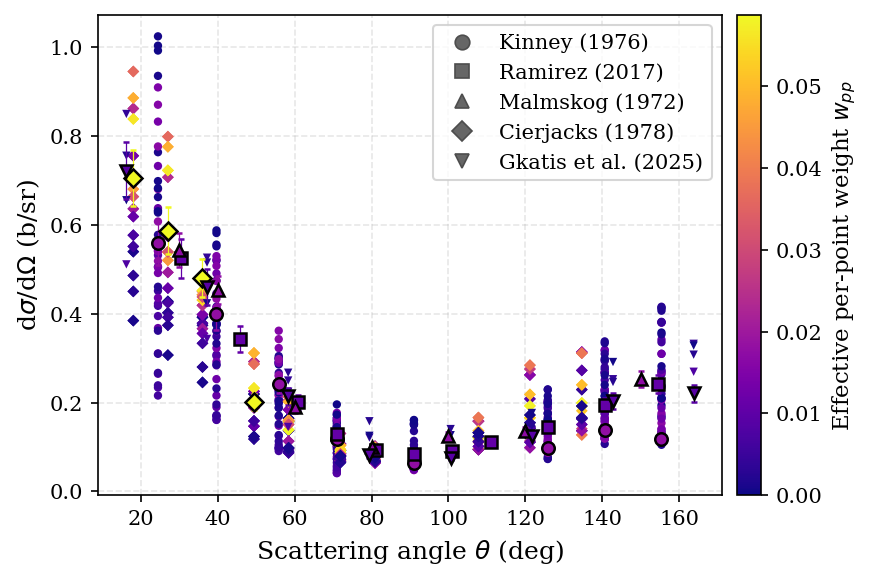

In [5]:
# Compute for E=1.3 MeV for the plot
diag_plot = compute_weights_for_bin(1.3, grid, bin_boundaries, exfor_cache, tof_map, label_map)
new_ds = diag_plot["new_datasets"]
exp_ids_plot = diag_plot["exp_ids"]
bin_energy = diag_plot["bin_energy"]
bin_lo, bin_hi = diag_plot["bin_lo"], diag_plot["bin_hi"]

fig, ax = plt.subplots(figsize=(6, 4))

all_ppw = [d["new_ppw"] for d in new_ds]
w_norm = mcolors.Normalize(vmin=0, vmax=max(all_ppw))
sm = cm.ScalarMappable(cmap=CMAP, norm=w_norm)
sm.set_array([])

exp_marker = {eid: MARKERS[i % len(MARKERS)] for i, eid in enumerate(exp_ids_plot)}

for eid in exp_ids_plot:
    marker = exp_marker[eid]
    ds_list = [d for d in new_ds if d["exp_id"] == eid]

    non_core = [d for d in ds_list if not d["is_core"]]
    if non_core:
        angles = np.concatenate([d["angle"] for d in non_core])
        values = np.concatenate([d["dsig"] for d in non_core])
        colors = np.concatenate([
            np.full(len(d["angle"]), d["new_ppw"]) for d in non_core
        ])
        ax.scatter(
            angles, values,
            c=CMAP(w_norm(colors)),
            marker=marker, s=16,
            edgecolors="none", linewidths=0.3,
            zorder=2,
        )

    core = [d for d in ds_list if d["is_core"]]
    for d in core:
        color = CMAP(w_norm(d["new_ppw"]))
        ax.errorbar(
            d["angle"], d["dsig"],
            yerr=d["error"],
            fmt=marker,
            color=color,
            markeredgecolor="black",
            markeredgewidth=1.2,
            markersize=6.0,
            capsize=1.5, capthick=0.6, elinewidth=0.6,
            ecolor=color,
            zorder=4,
            label="_nolegend_",
        )

cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Effective per-point weight $w_{pp}$", fontsize=11)

legend_handles = []
for eid in exp_ids_plot:
    marker = exp_marker[eid]
    label = label_map.get(eid, eid)
    handle = Line2D(
        [0], [0], marker=marker, color="none",
        markerfacecolor="0.4", markeredgecolor="0.3",
        markersize=7, markeredgewidth=0.8, label=label,
    )
    legend_handles.append(handle)

ax.legend(handles=legend_handles, loc="upper right", frameon=True,
          fancybox=True, fontsize=10, ncol=1)

ax.set_xlabel(r"Scattering angle $\theta$ (deg)")
ax.set_ylabel(r"d$\sigma$/d$\Omega$ (b/sr)")

plt.tight_layout()
plt.show()

## 5. Correlation diagnostic: GLS-ESS vs γ-power at the target energies

Using the same `TARGET_ENERGIES` bins from Section 3:
- **HHI (Herfindahl index)**: measures weight concentration. Lower = more equitable.
  Ideal HHI = 1/n_exp (perfectly equal).
- **WLS fraction bar chart**: side-by-side comparison per experiment.
- **ρ and n_eff**: how the equicorrelation model adapts to each experiment.

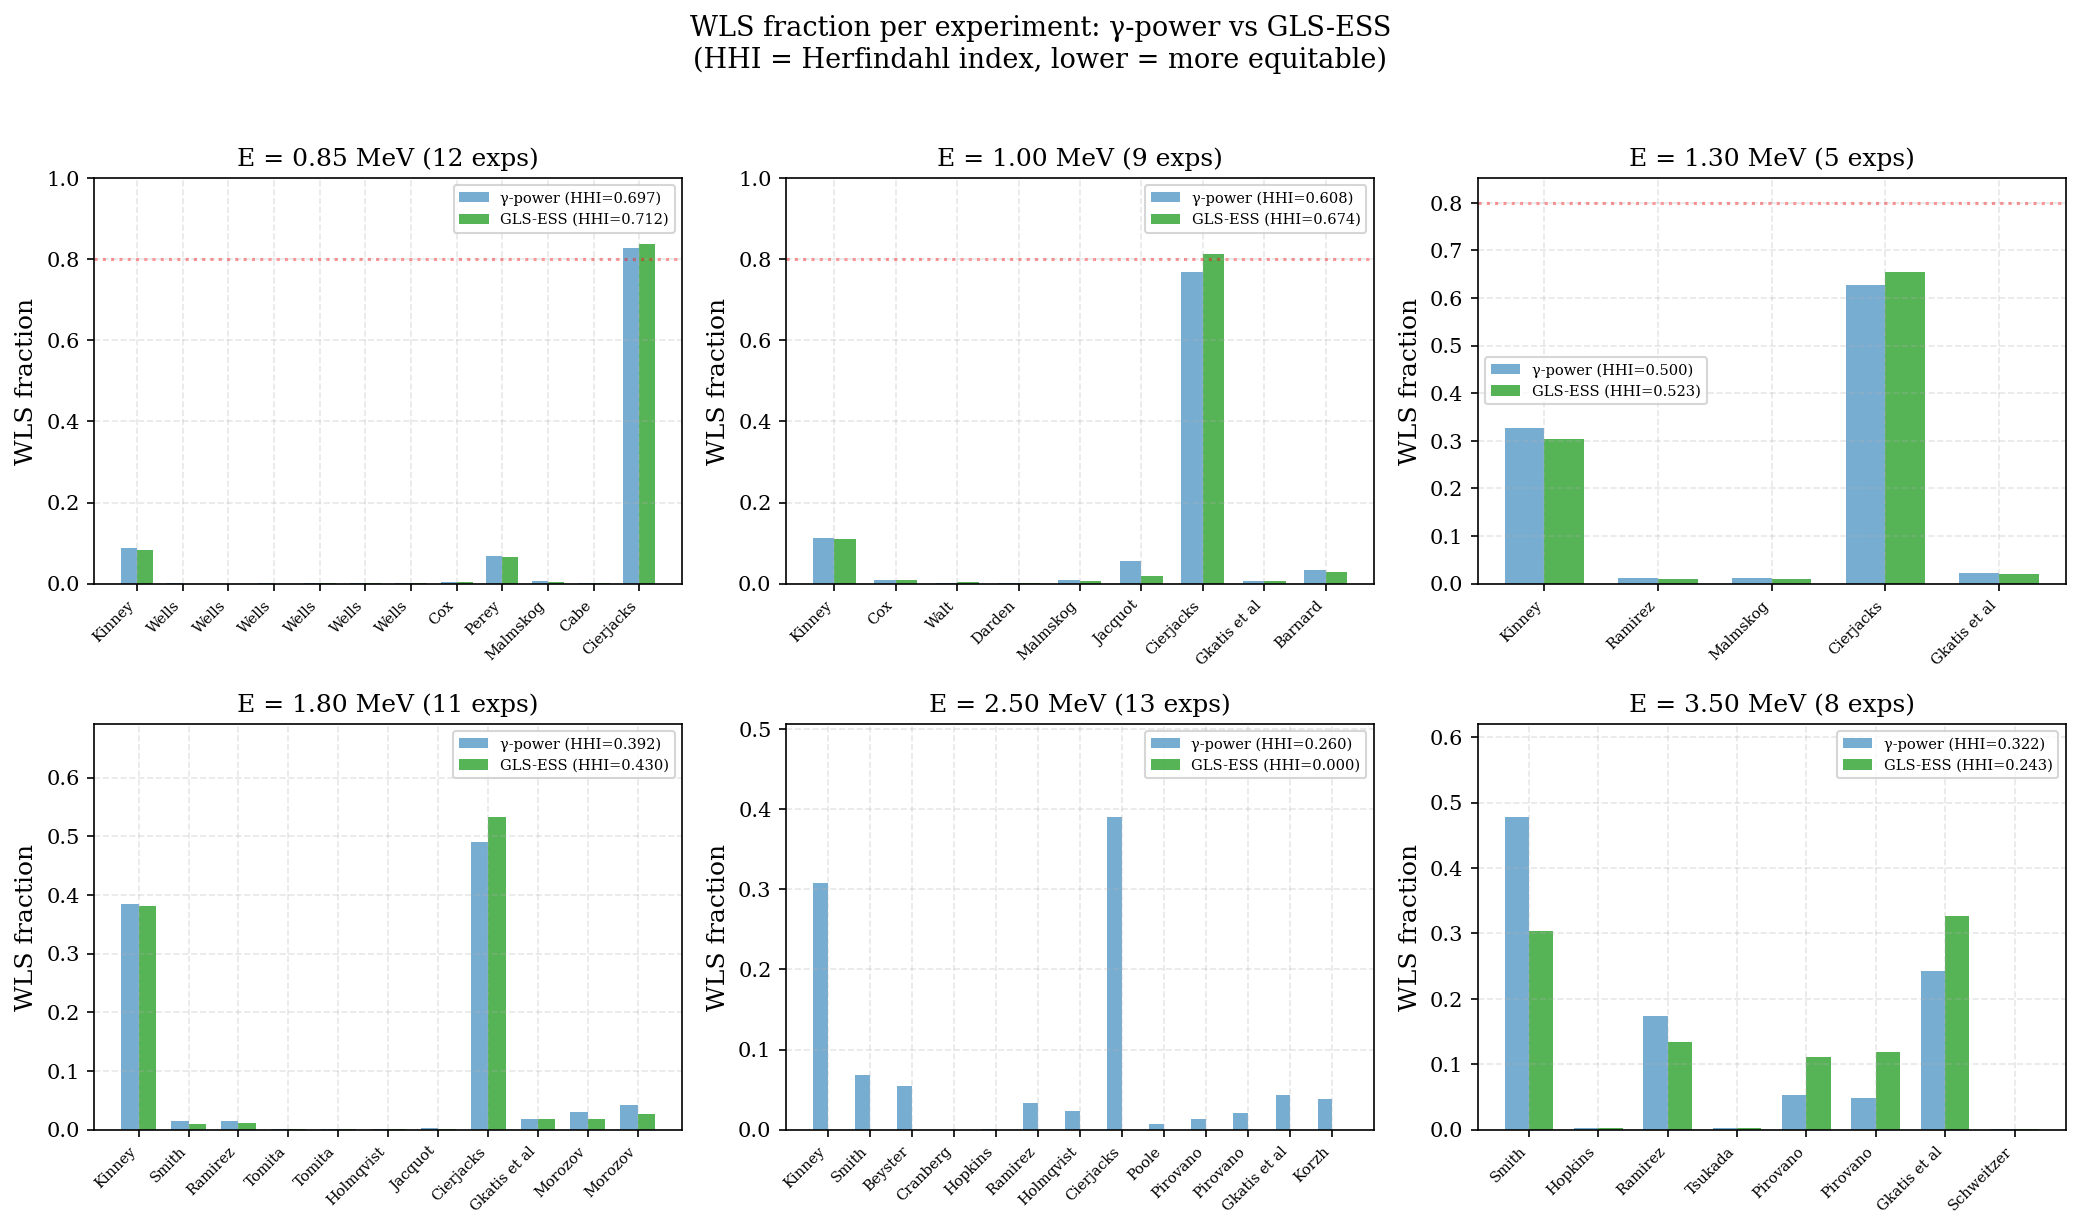


Herfindahl-Hirschman Index (HHI) comparison:
  Energy | n_exp |  HHI_old |  HHI_new |        Δ |      1/n
---------+-------+----------+----------+----------+---------
    0.85 |    12 |   0.6971 |   0.7116 | +0.0145 |   0.0833
    1.00 |     9 |   0.6084 |   0.6736 | +0.0652 |   0.1111
    1.30 |     5 |   0.4998 |   0.5228 | +0.0231 |   0.2000
    1.80 |    11 |   0.3917 |   0.4302 | +0.0385 |   0.0909
    2.50 |    13 |   0.2600 |   0.0000 | -0.2600 |   0.0769
    3.50 |     8 |   0.3217 |   0.2432 | -0.0785 |   0.1250


Per-experiment ρ and n_eff summary across diagnostic energies:
Experiment                     | n_core | σ̄_stat |      ρ |  n_eff |  g_GLS | g_γ=0.5
-------------------------------+--------+---------+--------+--------+--------+--------
Kinney (1976)                  |      8 |   9.9% |  0.204 |   3.30 |  0.412 |   0.354
Wells (1963)                   |      1 |  22.1% |  0.049 |   1.00 |  1.000 |   1.000
Wells (1963)                   |      1 |  18.1% |  0.071 |  

In [6]:
# ── 5. HHI + WLS fraction bar charts + ρ summary for TARGET_ENERGIES ──

DIAG_ENERGIES = [0.85, 1.0, 1.3, 1.8, 2.5, 3.5]

# Collect diagnostics
diag_results = {}
for target_E in DIAG_ENERGIES:
    diag_results[target_E] = compute_weights_for_bin(
        target_E, grid, bin_boundaries, exfor_cache, tof_map, label_map)

# ── Plot: WLS fraction bar charts with HHI ──
n_plots = len(DIAG_ENERGIES)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax_idx, target_E in enumerate(DIAG_ENERGIES):
    ax = axes[ax_idx]
    diag = diag_results[target_E]
    exp_ids = diag["exp_ids"]
    n_exp = len(exp_ids)

    if n_exp == 0:
        ax.set_title(f"E = {target_E:.2f} MeV\n(no data)")
        continue

    old_wls = compute_wls_fractions(diag["old_datasets"], "old_ppw", exp_ids)
    new_wls = compute_wls_fractions(diag["new_datasets"], "new_ppw", exp_ids)

    f_old = np.array([old_wls.get(eid, 0) for eid in exp_ids])
    f_new = np.array([new_wls.get(eid, 0) for eid in exp_ids])

    hhi_old = np.sum(f_old**2)
    hhi_new = np.sum(f_new**2)

    x = np.arange(n_exp)
    width = 0.35
    short_labels = [label_map.get(eid, eid).split("(")[0].strip()[:12] for eid in exp_ids]

    ax.bar(x - width/2, f_old, width, label=f"γ-power (HHI={hhi_old:.3f})",
           alpha=0.6, color="C0")
    ax.bar(x + width/2, f_new, width, label=f"GLS-ESS (HHI={hhi_new:.3f})",
           alpha=0.8, color="C2")

    ax.axhline(0.80, color="red", ls=":", alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("WLS fraction")
    ax.set_title(f"E = {target_E:.2f} MeV ({n_exp} exps)")
    ax.legend(fontsize=7)
    ax.set_ylim(0, min(1.0, max(max(f_old), max(f_new)) * 1.3))

plt.suptitle("WLS fraction per experiment: γ-power vs GLS-ESS\n"
             "(HHI = Herfindahl index, lower = more equitable)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Summary tables ──

# HHI comparison
print("\nHerfindahl-Hirschman Index (HHI) comparison:")
print(f"{'Energy':>8s} | {'n_exp':>5s} | {'HHI_old':>8s} | {'HHI_new':>8s} | {'Δ':>8s} | {'1/n':>8s}")
print(f"{'-'*8}-+-{'-'*5}-+-{'-'*8}-+-{'-'*8}-+-{'-'*8}-+-{'-'*8}")
for target_E in DIAG_ENERGIES:
    diag = diag_results[target_E]
    exp_ids = diag["exp_ids"]
    n_exp = len(exp_ids)
    if n_exp == 0:
        continue
    old_wls = compute_wls_fractions(diag["old_datasets"], "old_ppw", exp_ids)
    new_wls = compute_wls_fractions(diag["new_datasets"], "new_ppw", exp_ids)
    f_old = np.array([old_wls.get(eid, 0) for eid in exp_ids])
    f_new = np.array([new_wls.get(eid, 0) for eid in exp_ids])
    hhi_old = np.sum(f_old**2)
    hhi_new = np.sum(f_new**2)
    ideal = 1.0 / n_exp
    print(f"{target_E:8.2f} | {n_exp:5d} | {hhi_old:8.4f} | {hhi_new:8.4f} | "
          f"{hhi_new - hhi_old:+7.4f} | {ideal:8.4f}")

# ρ and n_eff summary across all diagnostic energies
print("\n\nPer-experiment ρ and n_eff summary across diagnostic energies:")
print(f"{'Experiment':<30s} | {'n_core':>6s} | {'σ̄_stat':>7s} | {'ρ':>6s} | {'n_eff':>6s} | {'g_GLS':>6s} | {'g_γ=0.5':>7s}")
print(f"{'-'*30}-+-{'-'*6}-+-{'-'*7}-+-{'-'*6}-+-{'-'*6}-+-{'-'*6}-+-{'-'*7}")

# Collect unique (experiment, n_core, rho) across all energies
seen = set()
for target_E in DIAG_ENERGIES:
    diag = diag_results[target_E]
    for exp_id in diag["exp_ids"]:
        cores = [d for d in diag["new_datasets"] if d["exp_id"] == exp_id and d["is_core"]]
        if not cores:
            continue
        c = cores[0]
        key = (exp_id, c["n_core"])
        if key in seen:
            continue
        seen.add(key)
        g_gamma = c["n_core"] ** (WEIGHT_GAMMA_OLD - 1.0)
        g_gls = 1.0 / (1.0 + max(c["n_core"] - 1, 0) * c["rho"])
        label = label_map.get(exp_id, exp_id)[:30]
        print(f"{label:<30s} | {c['n_core']:6d} | {c['rms_rel_stat']:6.1%} | "
              f"{c['rho']:6.3f} | {c['n_eff']:6.2f} | {g_gls:6.3f} | {g_gamma:7.3f}")